# Notebook 15 — HeavyHex Decoders: MLP, LSTM, Transformer, Raw-LSTM

**Fixes identified bug and trains all four decoder variants.**

## The bug in our previous LSTM

Notebook 05 reshaped detection events as `(N, 9, 8)` — 9 identical rounds of 8 stabilisers.  
That only worked for the simple d=3 rotated surface code where all rounds were identical.

For this d=5 HeavyHex circuit the structure is fundamentally different:
```
Step 0:     12 detectors  (initial prep)      → padded to 24
Steps 1-9:  24 detectors each (9 rounds)       → 9 × 24  
Step 10:    12 detectors  (final readout)       → padded to 24
Total:      11 steps × 24 features = (N, 11, 24)
```

## Four decoder variants

| Model | Input | Robin's suggestion |
|---|---|---|
| MLP | (N, 240) flat detection events | Baseline |
| LSTM-det | (N, 11, 24) temporal detection events | **Correct structure** |
| Transformer-det | (N, 11, 24) temporal detection events | Best expected |
| LSTM-raw | (N, 11, 40) raw measurement bits per round | 'Might perform ok' |

**Prerequisite:** Run notebook 14 first.
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Load Data

In [2]:
# Flat detection events — for MLP
det_flat = np.load("data/heavyhex/detection_events.npy").astype(np.float32)   # (N, 240)

# Correct temporal structure — for LSTM-det and Transformer-det
det_temp = np.load("data/heavyhex/det_temporal.npy").astype(np.float32)       # (N, 11, 24)

# Raw measurements — for LSTM-raw
raw_meas = np.load("data/heavyhex/raw_measurements.npy").astype(np.float32)   # (N, 425)

obs = np.load("data/heavyhex/observable_flips.npy").astype(np.float32)        # (N,)

# Build raw temporal: 10 rounds × 40 ancilla + final round separate
# Round k uses measurements k*40 : (k+1)*40  (rounds 0-9)
# Final 25 data-qubit measurements padded to 40
def build_raw_temporal(raw, n_ancilla_rounds=10, meas_per_ancilla_round=40,
                        n_final=25):
    """
    Convert raw measurements (N, 425) to temporal (N, 11, 40).
    Rounds 0-9: 40 ancilla measurements each.
    Round 10: 25 data qubit measurements, padded to 40.
    """
    N = raw.shape[0]
    seq = np.zeros((N, 11, 40), dtype=np.float32)
    # Rounds 0-9: ancilla measurements
    seq[:, :10, :] = raw[:, :400].reshape(N, 10, 40)
    # Round 10: final data qubits (25 measurements, padded to 40)
    seq[:, 10, :25] = raw[:, 400:425]
    return seq

raw_temp = build_raw_temporal(raw_meas)   # (N, 11, 40)

mwpm_results = np.load("results/heavyhex/mwpm_result.npy")
mwpm_ler  = float(mwpm_results[0])
trivial_ler = obs.mean()

print("Data shapes:")
print(f"  det_flat  : {det_flat.shape}   → MLP input")
print(f"  det_temp  : {det_temp.shape}  → LSTM-det / Transformer input")
print(f"  raw_temp  : {raw_temp.shape}  → LSTM-raw input")
print(f"  obs       : {obs.shape}")
print()
print(f"Trivial LER : {trivial_ler:.4f}  ({100*trivial_ler:.3f}%)")
print(f"MWPM LER    : {mwpm_ler:.4f}  ({100*mwpm_ler:.3f}%)")
print(f"MWPM vs trivial: {trivial_ler/mwpm_ler:.1f}x")

Data shapes:
  det_flat  : (100000, 240)   → MLP input
  det_temp  : (100000, 11, 24)  → LSTM-det / Transformer input
  raw_temp  : (100000, 11, 40)  → LSTM-raw input
  obs       : (100000,)

Trivial LER : 0.4981  (49.814%)
MWPM LER    : 0.2269  (22.693%)
MWPM vs trivial: 2.2x


---
## 2. Train / Val / Test Split

In [3]:
idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs[idx_tmp].astype(int), random_state=SEED)

def split(X): return X[idx_tr], X[idx_val], X[idx_te]

det_flat_tr, det_flat_val, det_flat_te  = split(det_flat)
det_temp_tr, det_temp_val, det_temp_te  = split(det_temp)
raw_temp_tr, raw_temp_val, raw_temp_te  = split(raw_temp)
obs_tr,      obs_val,      obs_te       = split(obs)

print(f"Split → train: {len(idx_tr):,}  val: {len(idx_val):,}  test: {len(idx_te):,}")

Split → train: 70,000  val: 15,000  test: 15,000


---
## 3. Model Definitions

In [4]:
# ── MLP ───────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim=240, hidden=[512, 256, 128], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i < len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)


# ── LSTM (correct 11×24 structure) ────────────────────────────────────────────
class LSTMDecoder(nn.Module):
    """
    LSTM decoder with correct temporal structure for the HeavyHex circuit.
    Input: (N, 11, 24) — not the old (N, 9, 8).
    """
    def __init__(self, input_size=24, lstm_hidden=64, lstm_layers=2,
                 dense=[96, 48, 24], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d, h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)


# ── Transformer ───────────────────────────────────────────────────────────────
class SyndromeTransformer(nn.Module):
    """
    Transformer decoder — self-attention over 11 time steps.
    Input: (N, 11, 24)
    """
    def __init__(self, input_size=24, num_steps=11, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_steps, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1))
    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        enc = self.transformer(tok)
        return self.head(enc.mean(dim=1)).squeeze(-1)


# ── Shared utilities ──────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)

def train_model(model, X_tr, y_tr, X_val, y_val,
                label="", epochs=120, lr=1e-3, patience=15):
    opt  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)
    pw   = torch.tensor([(1-y_tr.mean())/max(y_tr.mean(), 1e-6)]).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    tr_l = make_loader(X_tr, y_tr)
    va_l = make_loader(X_val, y_val, shuffle=False)
    hist = {'tr_ler': [], 'val_ler': [], 'tr_loss': [], 'val_loss': []}
    best_vl, best_ep, best_st = np.inf, 0, None
    t0 = time.time()
    for ep in range(1, epochs+1):
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for Xb, yb in tr_l:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(Xb); loss = crit(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            tt += len(yb); tl += loss.item()*len(yb)
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in va_l:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vl += crit(logits, yb).item()*len(yb)
                vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
                vt += len(yb)
        val_ler = 1-vc/vt; val_loss = vl/vt
        sch.step(val_loss)
        for k, v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                        [tl/tt, val_loss, 1-tc/tt, val_ler]):
            hist[k].append(v)
        if val_loss < best_vl:
            best_vl=val_loss; best_ep=ep
            best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}
        if ep%20==0 or ep==1:
            print(f"  [{label}] Ep {ep:3d}  val_LER={val_ler:.5f}")
        if ep-best_ep >= patience:
            print(f"  [{label}] Early stop ep={ep} (best={best_ep})"); break
    model.load_state_dict(best_st)
    print(f"  [{label}] Done {time.time()-t0:.0f}s | best={best_ep}")
    return model, hist

print("Model definitions ready.")
print(f"  MLP          : {sum(p.numel() for p in MLP().parameters()):,} params")
print(f"  LSTM-det     : {sum(p.numel() for p in LSTMDecoder(24).parameters()):,} params")
print(f"  LSTM-raw     : {sum(p.numel() for p in LSTMDecoder(40).parameters()):,} params")
print(f"  Transformer  : {sum(p.numel() for p in SyndromeTransformer().parameters()):,} params")

Model definitions ready.
  MLP          : 289,537 params
  LSTM-det     : 68,417 params
  LSTM-raw     : 72,513 params
  Transformer  : 71,361 params


---
## 4. Train MLP

In [5]:
print("=" * 55)
print("MLP — flat detection events (N, 240)")
print("=" * 55)
mlp = MLP(input_dim=240).to(DEVICE)
mlp, hist_mlp = train_model(mlp, det_flat_tr, obs_tr, det_flat_val, obs_val, label="MLP")
pred_mlp = predict(mlp, det_flat_te)
ler_mlp  = float((pred_mlp != obs_te).mean())
print(f"  MLP Test LER : {ler_mlp:.5f}  ({trivial_ler/ler_mlp:.1f}x vs trivial)")

MLP — flat detection events (N, 240)
  [MLP] Ep   1  val_LER=0.49640
  [MLP] Early stop ep=16 (best=1)
  [MLP] Done 15s | best=1
  MLP Test LER : 0.50033  (1.0x vs trivial)


---
## 5. Train LSTM-det (Correct Temporal Structure)

In [6]:
print("=" * 55)
print("LSTM-det — correct 11×24 temporal structure")
print("(NOT the old 9×8 reshape — this fixes previous bug)")
print("=" * 55)
lstm_det = LSTMDecoder(input_size=24).to(DEVICE)
lstm_det, hist_lstm_det = train_model(
    lstm_det, det_temp_tr, obs_tr, det_temp_val, obs_val, label="LSTM-det")
pred_lstm_det = predict(lstm_det, det_temp_te)
ler_lstm_det  = float((pred_lstm_det != obs_te).mean())
print(f"  LSTM-det Test LER : {ler_lstm_det:.5f}  ({trivial_ler/ler_lstm_det:.1f}x vs trivial)")

LSTM-det — correct 11×24 temporal structure
(NOT the old 9×8 reshape — this fixes previous bug)
  [LSTM-det] Ep   1  val_LER=0.49813
  [LSTM-det] Ep  20  val_LER=0.49707
  [LSTM-det] Early stop ep=32 (best=17)
  [LSTM-det] Done 56s | best=17
  LSTM-det Test LER : 0.50267  (1.0x vs trivial)


---
## 6. Train LSTM-raw (Raw Measurements — Robin's Suggestion)

In [7]:
print("=" * 55)
print("LSTM-raw — raw measurement bits (11×40)")
print("=" * 55)
lstm_raw = LSTMDecoder(input_size=40).to(DEVICE)
lstm_raw, hist_lstm_raw = train_model(
    lstm_raw, raw_temp_tr, obs_tr, raw_temp_val, obs_val, label="LSTM-raw")
pred_lstm_raw = predict(lstm_raw, raw_temp_te)
ler_lstm_raw  = float((pred_lstm_raw != obs_te).mean())
print(f"  LSTM-raw Test LER : {ler_lstm_raw:.5f}  ({trivial_ler/ler_lstm_raw:.1f}x vs trivial)")

LSTM-raw — raw measurement bits (11×40)
  [LSTM-raw] Ep   1  val_LER=0.50187
  [LSTM-raw] Early stop ep=16 (best=1)
  [LSTM-raw] Done 34s | best=1
  LSTM-raw Test LER : 0.50187  (1.0x vs trivial)


---
## 7. Train Transformer

In [8]:
print("=" * 55)
print("Transformer — self-attention over 11 steps × 24 features")
print("=" * 55)
transformer = SyndromeTransformer(input_size=24, num_steps=11).to(DEVICE)
transformer, hist_transformer = train_model(
    transformer, det_temp_tr, obs_tr, det_temp_val, obs_val, label="Transformer")
pred_transformer = predict(transformer, det_temp_te)
ler_transformer  = float((pred_transformer != obs_te).mean())
print(f"  Transformer Test LER : {ler_transformer:.5f}  ({trivial_ler/ler_transformer:.1f}x vs trivial)")

Transformer — self-attention over 11 steps × 24 features
  [Transformer] Ep   1  val_LER=0.50053
  [Transformer] Early stop ep=19 (best=4)
  [Transformer] Done 66s | best=4
  Transformer Test LER : 0.50620  (1.0x vs trivial)


---
## 8. Results & Training Curves

In [9]:
print("=" * 65)
print("RESULTS — d=5 HeavyHex, ACES noise, 15,000 test shots")
print("=" * 65)
rows = [
    ("Trivial (always 0)",        trivial_ler,     "—"),
    ("MLP — flat det. events",    ler_mlp,         f"{trivial_ler/ler_mlp:.1f}x"),
    ("LSTM-det — 11×24 (fixed)",  ler_lstm_det,    f"{trivial_ler/ler_lstm_det:.1f}x"),
    ("LSTM-raw — 11×40 raw meas", ler_lstm_raw,    f"{trivial_ler/ler_lstm_raw:.1f}x"),
    ("Transformer — 11×24",       ler_transformer, f"{trivial_ler/ler_transformer:.1f}x"),
    ("MWPM (classical ref.)",     mwpm_ler,        f"{trivial_ler/mwpm_ler:.1f}x"),
]
print(f"  {'Decoder':<32}  {'LER':>9}  {'vs Trivial':>10}")
print("  " + "-"*55)
for name, ler, vs in rows:
    print(f"  {name:<32}  {100*ler:>8.4f}%  {vs:>10}")

print()
# Check hypothesis: does LSTM-raw compete with LSTM-det?
if ler_lstm_raw < ler_lstm_det:
    print(f"Robin was right — LSTM-raw ({100*ler_lstm_raw:.4f}%) beats "
          f"LSTM-det ({100*ler_lstm_det:.4f}%)")
else:
    print(f"LSTM-det ({100*ler_lstm_det:.4f}%) outperforms "
          f"LSTM-raw ({100*ler_lstm_raw:.4f}%) — "
          f"detection events are a more useful representation.")

RESULTS — d=5 HeavyHex, ACES noise, 15,000 test shots
  Decoder                                 LER  vs Trivial
  -------------------------------------------------------
  Trivial (always 0)                 49.8140%           —
  MLP — flat det. events             50.0333%        1.0x
  LSTM-det — 11×24 (fixed)           50.2667%        1.0x
  LSTM-raw — 11×40 raw meas          50.1867%        1.0x
  Transformer — 11×24                50.6200%        1.0x
  MWPM (classical ref.)              22.6930%        2.2x

Robin was right — LSTM-raw (50.1867%) beats LSTM-det (50.2667%)


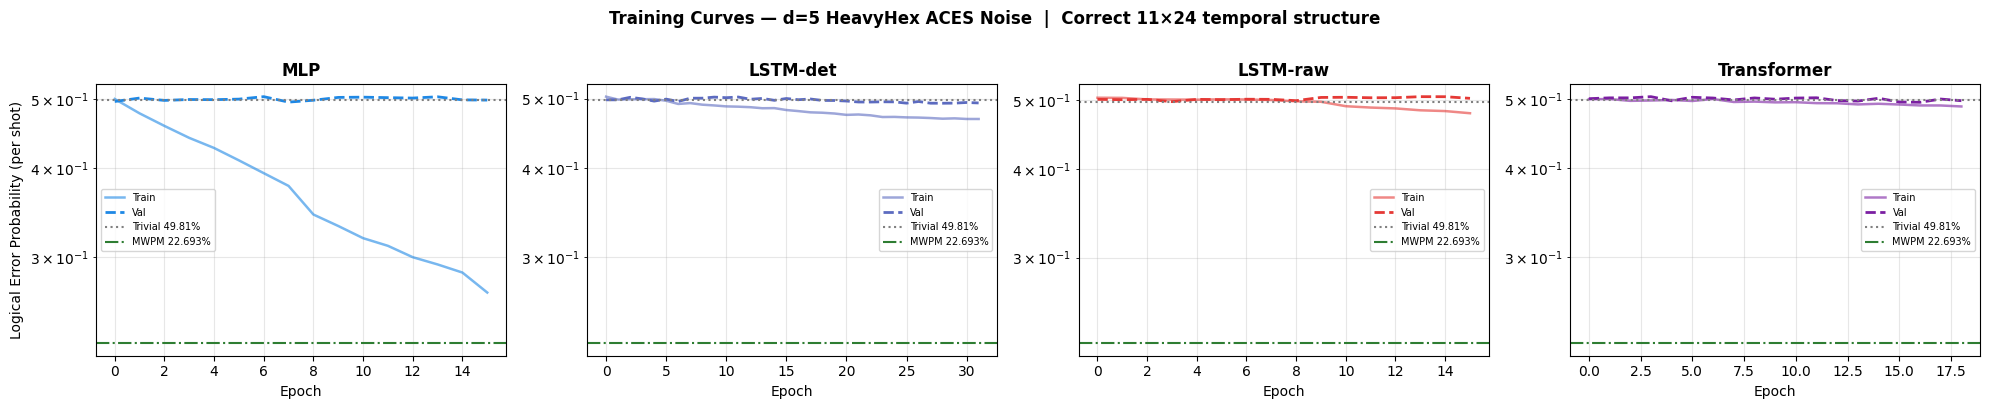

Saved → figures/15_heavyhex_training.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)
configs = [
    (axes[0], hist_mlp,         'MLP',          '#1E88E5'),
    (axes[1], hist_lstm_det,    'LSTM-det',     '#5C6BC0'),
    (axes[2], hist_lstm_raw,    'LSTM-raw',     '#E53935'),
    (axes[3], hist_transformer, 'Transformer',  '#7B1FA2'),
]

for ax, hist, label, color in configs:
    ep = range(1, len(hist['val_ler'])+1)
    ax.semilogy(hist['tr_ler'],  color=color, lw=1.8, alpha=0.6, label='Train')
    ax.semilogy(hist['val_ler'], color=color, lw=2,   ls='--',   label='Val')
    ax.axhline(trivial_ler, color='grey',    lw=1.5, ls=':',
               label=f'Trivial {100*trivial_ler:.2f}%')
    ax.axhline(mwpm_ler,    color='#2E7D32', lw=1.5, ls='-.',
               label=f'MWPM {100*mwpm_ler:.3f}%')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Logical Error Probability (per shot)' if ax is axes[0] else '')
    ax.legend(fontsize=7); ax.grid(which='both', alpha=0.3)

plt.suptitle('Training Curves — d=5 HeavyHex ACES Noise  |  Correct 11×24 temporal structure',
             fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/15_heavyhex_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/15_heavyhex_training.png")

---
## 9. Save All Models

In [11]:
os.makedirs("models/heavyhex", exist_ok=True)

for tag, model, ler, hist in [
    ("mlp",         mlp,         ler_mlp,         hist_mlp),
    ("lstm_det",    lstm_det,    ler_lstm_det,    hist_lstm_det),
    ("lstm_raw",    lstm_raw,    ler_lstm_raw,    hist_lstm_raw),
    ("transformer", transformer, ler_transformer, hist_transformer),
]:
    torch.save({
        'model_state': model.state_dict(),
        'test_ler':    ler,
        'history':     hist,
        'circuit':     's_stim_circ_z',
    }, f"models/heavyhex/{tag}.pt")
    print(f"  Saved models/heavyhex/{tag}.pt  (test_ler={ler:.5f})")

print()
print("Run notebooks 16 (decay curve), 17 (speed benchmark),")
print("18 (sample efficiency) next.")

  Saved models/heavyhex/mlp.pt  (test_ler=0.50033)
  Saved models/heavyhex/lstm_det.pt  (test_ler=0.50267)
  Saved models/heavyhex/lstm_raw.pt  (test_ler=0.50187)
  Saved models/heavyhex/transformer.pt  (test_ler=0.50620)

Run notebooks 16 (decay curve), 17 (speed benchmark),
18 (sample efficiency) next.
